# Assignment 5
## Part 1: Affine Factorization
Mohammad Rashiqul Alam  
malam25@illinois.edu  

In [5]:
# Imports
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from glob import glob

### Step 1 — Load and Normalize the Measurement Matrix

Load the data matrix and normalize the point coordinates by translating them to the mean of the points in each view (see lecture for details).

Each frame contributes two rows of the measurement matrix (x and y coordinates).  
Following the affine structure-from-motion formulation by Tomasi and Kanade, I subtract the centroid of the tracked feature points in each view to remove image-plane translations before performing the rank-3 SVD in the next step.

In [6]:
def load_measurements(img_file_path, meas_file_path):
    """
    Loads the Tomasi–Kanade hotel sequence data:
      - Reads the measurement matrix (2M x N)
      - Collects paths to all image frames in correct sorted order
      - Computes per-view centroids (x̄, ȳ) and returns centered coordinates

    Args:
        img_file_path (str): Path to the directory containing frame JPGs.
        meas_file_path (str): Path to the measurement_matrix.txt file.

    Returns:
        D_tilde (ndarray): Centered measurement matrix (2M x N)
        means (ndarray): Per-row mean values (2M x 1)
        img_files (list[str]): Sorted list of image paths
        D (ndarray): Original measurement matrix before centering
    """
    # Load measurement matrix from text file 
    D = np.loadtxt(meas_file_path)  # D shape: (2M, N)
    rows, N = D.shape
    assert rows % 2 == 0, "Expected 2M rows (x,y per view)"
    M = rows // 2  # Number of views (frames)
    print(f"Loaded measurement matrix: {rows}x{N}  (M={M} views, N={N} points)")

    # Collect image files and sort them to match measurement matrix order
    img_files = sorted(glob(os.path.join(img_file_path, "frame*.jpg")))
    if len(img_files) != M:
        print(f"⚠️ Warning: found {len(img_files)} images but {M} views in matrix.")
    else:
        print(f"Found {len(img_files)} corresponding image frames.")

    # Center each view by subtracting the mean (centroid) of each row 
    means = np.zeros((rows, 1))  # To store mean x and y for each view
    D_tilde = D.copy()           # Copy of D to store centered data
    for i in range(M):
        r0, r1 = 2*i, 2*i+1      # Row indices for x and y of view i
        mu_x = D[r0].mean()      # Mean x for view i
        mu_y = D[r1].mean()      # Mean y for view i
        means[r0, 0] = mu_x      # Store mean x
        means[r1, 0] = mu_y      # Store mean y
        D_tilde[r0] -= mu_x      # Subtract mean x from all x-coords in view i
        D_tilde[r1] -= mu_y      # Subtract mean y from all y-coords in view i

    # Means of first view should be ~0 after centering 
    print(f"Centered first view mean check: {D_tilde[0].mean():.4f}, {D_tilde[1].mean():.4f}")
    return D_tilde, means, img_files, D

In [7]:
# Set the directory containing the image frames
img_dir = "/home/rashiqul/workspace/ece549/notebooks/factorization_data"

# Set the path to the measurement matrix text file
meas_path = img_dir + "/measurement_matrix.txt"

# Load and center the measurement matrix, get per-view means, image file list, and original matrix
D_tilde, means, img_files, D = load_measurements(img_dir, meas_path)

# Verify global centering is effective across all views
print("\nGlobal centering verification:")
print(f"  Mean of all rows in D_tilde: {D_tilde.mean(axis=1).max():.2e}")
print(f"  This should be ~0 for all 2M={D_tilde.shape[0]} rows")

Loaded measurement matrix: 202x215  (M=101 views, N=215 points)
Found 101 corresponding image frames.
Centered first view mean check: 0.0000, 0.0000

Global centering verification:
  Mean of all rows in D_tilde: 8.80e-14
  This should be ~0 for all 2M=202 rows


### Step 2 — Rank-3 SVD and Initial Motion/Structure

After centering the measurement matrix $D$ (Step-1), factorize the centered matrix $\tilde{D}$ with SVD and keep the **top three** singular values to obtain the best rank-3 approximation in the Frobenius sense. Let

$$
\tilde{D} \approx U_{2M \times 3}\, \Sigma_{3 \times 3}\, V_{3 \times N}^\top.
$$

Following Tomasi–Kanade, define the initial motion and structure as

$$
M_0 = U\, \Sigma^{1/2}, \qquad S_0 = \Sigma^{1/2} V^\top.
$$

This yields $\tilde{D} \approx M_0 S_0$ and sets us up for the metric upgrade in the next step.

In [8]:
def svd_rank3_factorization(D_tilde):
    """
    Apply SVD on the centered measurement matrix and extract
    the top-3 components to obtain initial motion (M0) and structure (S0).

    Args:
        D_tilde (ndarray): Centered measurement matrix of shape (2M, N).

    Returns:
        (M0, S0, svd_parts): default Python tuple where
            M0 (ndarray) -> (2M, 3)  initial motion
            S0 (ndarray) -> (3,  N)  initial structure
            svd_parts    -> (U3, S3, V3t)  raw truncated SVD pieces
    """
    # Compute full SVD of the centered measurement matrix
    U, s, Vt = np.linalg.svd(D_tilde, full_matrices=False)
    
    # Keep only the top-3 singular vectors/values for rank-3 approximation
    U3  = U[:, :3]           # (2M, 3) - left singular vectors (motion)
    S3  = np.diag(s[:3])     # (3, 3)  - top 3 singular values as diagonal matrix
    V3t = Vt[:3, :]          # (3, N)  - right singular vectors (structure)
    
    # Symmetric split using Σ^{1/2} for metric upgrade preparation
    W = np.sqrt(S3)          # (3, 3) - square root of singular values
    
    # Initial motion matrix: U3 * sqrt(S3)
    M0 = U3 @ W              # (2M, 3)
    
    # Initial structure matrix: sqrt(S3) * V3t
    S0 = W @ V3t             # (3, N)
    
    # Return both matrices and the truncated SVD parts for further use
    return M0, S0, (U3, S3, V3t)

In [9]:
# Compute the initial motion and structure matrices using rank-3 SVD factorization
M0, S0, (U3, S3, V3t) = svd_rank3_factorization(D_tilde)

# Print the shapes of the resulting matrices for verification
print("Shapes:")
print("  M0:", M0.shape, " (motion)")        # Motion matrix shape
print("  S0:", S0.shape, " (structure)")     # Structure matrix shape
print("  kept singular values:", np.diag(S3)) # Top 3 singular values kept

Shapes:
  M0: (202, 3)  (motion)
  S0: (3, 215)  (structure)
  kept singular values: [15830.96965136 13712.91580108  1552.96253721]


### Step 3 — Metric Upgrade / Eliminate Affine Ambiguity

After SVD there's one valid factorization  
$ D \approx M_0 S_0 $,  
but it is only defined up to any invertible $ 3 \times 3 $ transform $ A $:

$$
M = M_0 A, \qquad S = A^{-1} S_0.
$$

To enforce orthographic cameras, each $ 2 \times 3 $ motion block

$$
\begin{bmatrix}
a_i \\
b_i
\end{bmatrix}
$$

must have orthonormal rows:

$$
a_i^\top a_i = 1, \qquad b_i^\top b_i = 1, \qquad a_i^\top b_i = 0.
$$

Let $ L = AA^\top $ (symmetric). Using rows $ m_{i1}, m_{i2} $ from $ M_0 $, the constraints become linear in the six unique entries of $ L $:

$$
m_{i1}^\top L m_{i1} = 1, \qquad m_{i2}^\top L m_{i2} = 1, \qquad m_{i1}^\top L m_{i2} = 0.
$$

Stack all frames, solve for $ L $ by least squares, factor $ L = AA^\top $ (Cholesky or eigen), then set

$$
M = M_0 A, \qquad S = A^{-1} S_0.
$$

In [10]:
def phi(u, v=None):
    """
    Construct the vector of coefficients for the quadratic form u^T L v,
    where L is a symmetric 3x3 matrix parameterized by its six unique entries.
    Used to linearize the orthonormality constraints in the metric upgrade step.

    Args:
        u (array-like): 3-vector (row from motion matrix M0)
        v (array-like, optional): 3-vector. If None, uses u (for terms like u^T L u)

    Returns:
        np.ndarray: 6-element array corresponding to [L11, L12, L13, L22, L23, L33] coefficients
    """
    # If v is not provided, use u (for diagonal constraints)
    if v is None:
        v = u
    # Unpack vector components for clarity
    u1, u2, u3 = u
    v1, v2, v3 = v
    # Return the coefficients for the symmetric matrix L
    return np.array([
        u1*v1,                 # Coefficient for L11
        u1*v2 + u2*v1,         # Coefficient for L12 (appears twice in symmetric matrix)
        u1*v3 + u3*v1,         # Coefficient for L13 (appears twice)
        u2*v2,                 # Coefficient for L22
        u2*v3 + u3*v2,         # Coefficient for L23 (appears twice)
        u3*v3                  # Coefficient for L33
    ], dtype=float)

In [11]:
def metric_upgrade_from_M0(M0):
    """
    Estimate the metric upgrade matrix A (3x3) such that the rows of M = M0 @ A
    are orthonormal (i.e., each camera block is orthographic).
    Returns (A, L) where L = A @ A.T (symmetric positive semi-definite).

    Args:
        M0 (ndarray): Initial motion matrix (2M x 3) from SVD.

    Returns:
        A (ndarray): Metric upgrade matrix (3x3).
        L (ndarray): Symmetric matrix (3x3) satisfying the orthonormality constraints.
    """
    # Reshape M0 to get all 3D rows (2M rows, each 3D)
    rows = M0.reshape(-1, 3)
    assert rows.shape[0] % 2 == 0  # Should be even (pairs of rows per view)
    m = rows.shape[0] // 2         # Number of camera views

    G_list, c_list = [], []        # Lists to build the linear system

    # For each camera view, add three constraints:
    for i in range(m):
        a = rows[2*i    ]  # First row of camera i
        b = rows[2*i + 1]  # Second row of camera i

        # Constraint: a^T L a = 1 (row a is unit length)
        G_list.append(phi(a))
        c_list.append(1.0)
        # Constraint: b^T L b = 1 (row b is unit length)
        G_list.append(phi(b))
        c_list.append(1.0)
        # Constraint: a^T L b = 0 (rows a and b are orthogonal)
        G_list.append(phi(a, b))
        c_list.append(0.0)

    # Stack all constraints into matrix form G l = c
    G = np.vstack(G_list)
    c = np.asarray(c_list)

    # Solve for l (the six unique entries of symmetric matrix L) by least squares
    l, *_ = np.linalg.lstsq(G, c, rcond=None)
    L11, L12, L13, L22, L23, L33 = l
    # Construct the symmetric matrix L from its unique entries
    L = np.array([[L11, L12, L13],
                  [L12, L22, L23],
                  [L13, L23, L33]], dtype=float)

    # Project L to nearest symmetric positive definite matrix for numerical stability
    w, V = np.linalg.eigh((L + L.T)/2.0)
    w = np.clip(w, a_min=1e-10, a_max=None)  # Ensure eigenvalues are non-negative
    L_spd = (V * w) @ V.T

    # Cholesky decomposition (upper) so that A @ A.T = L_spd
    A = np.linalg.cholesky(L_spd).T
    return (A, L_spd)

In [12]:
def upgrade_motion_structure(M0, S0):
    """
    Perform the metric upgrade to eliminate affine ambiguity.
    Returns the upgraded motion and structure matrices, as well as the metric matrix A and L.

    Args:
        M0 (ndarray): Initial motion matrix (2M x 3) from SVD.
        S0 (ndarray): Initial structure matrix (3 x N) from SVD.

    Returns:
        M (ndarray): Upgraded motion matrix (2M x 3) with orthonormal rows.
        S (ndarray): Upgraded structure matrix (3 x N).
        A (ndarray): Metric upgrade matrix (3 x 3).
        L (ndarray): Symmetric matrix (3 x 3) from metric constraints.
    """
    A, L = metric_upgrade_from_M0(M0)   # Solve for metric upgrade matrix A and constraint matrix L
    A_inv = np.linalg.inv(A)            # Compute inverse of A for structure update
    M = M0 @ A                          # Upgrade motion: rows become orthonormal
    S = A_inv @ S0                      # Upgrade structure: apply inverse transform
    return (M, S, A, L)

In [13]:
# Perform the metric upgrade to eliminate affine ambiguity
M, S, A, L = upgrade_motion_structure(M0, S0)

# Print the metric upgrade matrix (A, called Q in the assignment)
print("A (Q in the assignment) =\n", A)

# Check orthonormality across all 101 camera views
print("\nOrthonormality diagnostics across all views:")
norms_a = []
norms_b = []
dots = []
for i in range(M.shape[0] // 2):
    a = M[2*i]      # First row of camera i
    b = M[2*i + 1]  # Second row of camera i
    norms_a.append(np.linalg.norm(a))
    norms_b.append(np.linalg.norm(b))
    dots.append(float(a @ b))

print(f"  ||a_i|| mean±std: {np.mean(norms_a):.4f}±{np.std(norms_a):.4f}")
print(f"  ||b_i|| mean±std: {np.mean(norms_b):.4f}±{np.std(norms_b):.4f}")
print(f"  a_i·b_i mean±std: {np.mean(dots):.2e}±{np.std(dots):.2e}")
print(f"  ✓ Values near 1,1,0 confirm successful orthographic metric upgrade")

A (Q in the assignment) =
 [[0.07963429 0.00099175 0.00269345]
 [0.         0.08481677 0.00587401]
 [0.         0.         0.04264539]]

Orthonormality diagnostics across all views:
  ||a_i|| mean±std: 1.0026±0.0136
  ||b_i|| mean±std: 0.9996±0.0041
  a_i·b_i mean±std: 2.24e-03±9.58e-03
  ✓ Values near 1,1,0 confirm successful orthographic metric upgrade


### Step 4 — Visualize the 3D Structure & Discuss Ambiguity

After the metric upgrade (Step 3), we have the Euclidean motion $ M $ and 3D structure $ S $ such that the centered measurement matrix is approximated by $ \tilde{D} \approx MS $.

Each column of $ S \in \mathbb{R}^{3 \times N} $ is a reconstructed 3D point (up to a global similarity transform).

**Ambiguity.** Under affine/orthographic SFM, the recovered shape is not unique: it is determined only up to a single global similarity transform (a 3D rotation, an optional reflection/mirroring, and a global scale), because these transformations do not change the image measurements after centering. In other words, your 3D point cloud can be spun, mirrored, and uniformly scaled without affecting the reprojection error. This is expected and acceptable for the assignment.

In [14]:
def _set_equal_3d_axes(ax, X, Y, Z):
    """
    Set equal aspect ratio for 3D plot axes to prevent distortion.
    
    This helper function calculates a cubic bounding box around the data
    and sets axis limits so all three dimensions have the same scale.
    This prevents the 3D point cloud from appearing stretched or squashed.

    Args:
        ax: Matplotlib 3D axes instance (from fig.add_subplot(111, projection='3d'))
        X (ndarray): 1D array of x-coordinates for all points
        Y (ndarray): 1D array of y-coordinates for all points
        Z (ndarray): 1D array of z-coordinates for all points
    """
    # Find the min and max values along each axis
    x_min, x_max = np.min(X), np.max(X)
    y_min, y_max = np.min(Y), np.max(Y)
    z_min, z_max = np.min(Z), np.max(Z)
    
    # Calculate the midpoint of the data along each axis
    x_mid, y_mid, z_mid = (x_min + x_max)/2, (y_min + y_max)/2, (z_min + z_max)/2
    
    # Find the maximum range among all three dimensions
    max_range = max(x_max - x_min, y_max - y_min, z_max - z_min)
    
    # Set radius as half of the maximum range (for cubic bounding box)
    r = max_range / 2.0
    
    # Set equal limits centered around midpoints for all three axes
    ax.set_xlim(x_mid - r, x_mid + r)
    ax.set_ylim(y_mid - r, y_mid + r)
    ax.set_zlim(z_mid - r, z_mid + r)

In [15]:
def center_structure_for_display(S):
    """
    Center the structure for visualization only (subtract 3D centroid).
    
    This function translates the 3D point cloud so its centroid is at the origin.
    Note: This is purely cosmetic for better visualization and does NOT affect
    the reconstruction correctness. The structure S is already valid from Step 3.

    Args:
        S (ndarray): shape (3, N), 3D points after metric upgrade.

    Returns:
        Sc (ndarray): shape (3, N), centered for plotting.
        mu  (ndarray): shape (3,), centroid that was subtracted.
    """
    # Compute the 3D centroid (mean of all points) along the point dimension
    mu = np.mean(S, axis=1, keepdims=True)   # Shape: (3, 1)
    
    # Subtract centroid from all points to center the cloud at origin
    Sc = S - mu                               # Purely for visualization aesthetics
    
    # Return centered structure and the centroid for reference
    return Sc, mu.ravel()

In [16]:
def plot_3d_structure(S, title="Recovered 3D Structure (Tomasi–Kanade)",
                      viewpoints=((20, -60), (10, 30), (60, 120)),
                      save_prefix=None, s=4):
    """
    Plot the 3D point cloud from S (3 x N) using several viewpoints.
    
    This function visualizes the reconstructed 3D structure by creating multiple
    scatter plots from different camera angles. The structure is centered at the
    origin for better visualization.

    Args:
        S (ndarray): shape (3, N), Euclidean structure after Step 3.
        title (str): title used for the first figure; others get suffixes.
        viewpoints (iterable): list/tuple of (elev, azim) pairs for 3D views.
        save_prefix (str or None): if provided, save PNGs as f"{save_prefix}_{k}.png".
        s (int/float): scatter marker size.

    Notes:
        - We center S for display so the object is near the origin.
        - Remaining similarity ambiguity (rotation/scale/mirror) is expected.
    """
    # Center the structure for nicer display (cosmetic only, doesn't affect correctness)
    S_vis, _ = center_structure_for_display(S)
    
    # Extract X, Y, Z coordinates for all N points
    X, Y, Z = S_vis[0, :], S_vis[1, :], S_vis[2, :]

    # Create a separate figure for each viewpoint
    for k, (elev, azim) in enumerate(viewpoints):
        fig = plt.figure()                              # Create new figure
        ax = fig.add_subplot(111, projection='3d')      # Add 3D axes
        ax.scatter(X, Y, Z, s=s)                        # Plot points as scatter
        _set_equal_3d_axes(ax, X, Y, Z)                 # Ensure equal aspect ratio
        
        # Set axis labels
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        
        # Set title (first view gets base title, others get numbered suffix)
        if k == 0:
            ax.set_title(title)
        else:
            ax.set_title(f"{title}  (view {k+1})")
        
        # Set the camera viewing angle (elevation and azimuth)
        ax.view_init(elev=elev, azim=azim)
        
        plt.tight_layout()                              # Adjust layout to prevent clipping
        
        # Optionally save the figure to disk
        if save_prefix:
            plt.savefig(f"{save_prefix}_{k+1}.png", dpi=200)
        
        plt.show()                                      # Display the plot

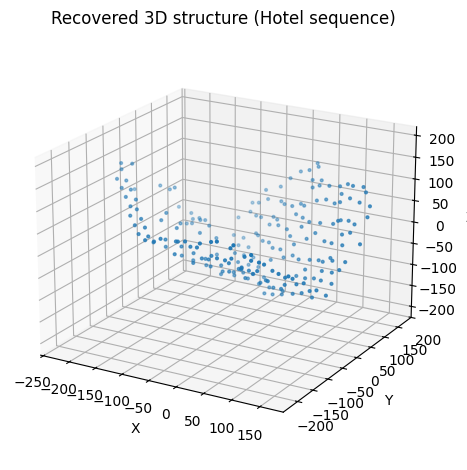

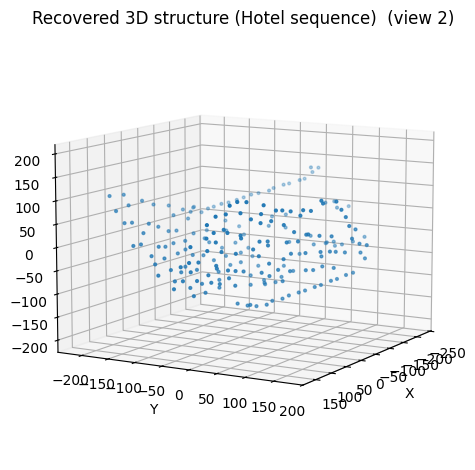

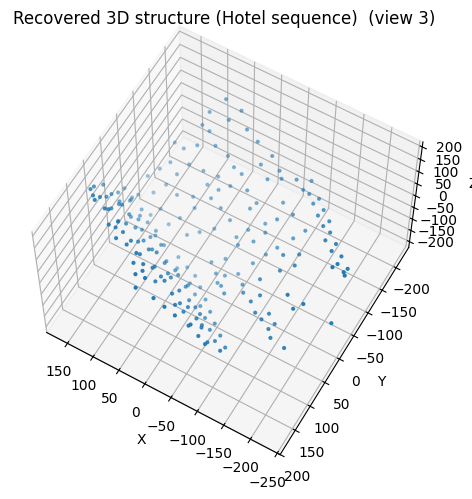

In [17]:
# Assume M, S are from Step 3 (after metric upgrade):
# M, S, Q, L = upgrade_motion_structure(M0, S0)

# Visualize the recovered 3D structure from S using multiple viewpoints.
# - title: Title for the plot window
# - viewpoints: List of (elevation, azimuth) pairs for camera angles
# - save_prefix: If not None, saves each view as PNG (disabled here)
# - s: Marker size for scatter plot
plot_3d_structure(
    S,
    title="Recovered 3D structure (Hotel sequence)",
    viewpoints=((20, -60), (10, 30), (60, 120)),
    save_prefix=None,   # e.g., "hotel_structure" to save PNGs
    s=4
)